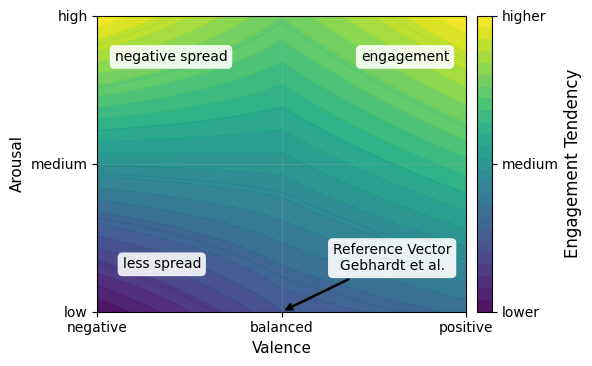

PosixPath('valence_arousal_engagement_infographic_contour.svg')

In [42]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Conceptual model based on the provided text, not empirical data
valence = np.linspace(-1, 1, 300)
arousal = np.linspace(0, 1, 300)
V, A = np.meshgrid(valence, arousal)

E = 0.55 * A
E += 0.25 * np.clip(V, 0, 1) * (0.4 + 0.6 * A)
E += 0.25 * np.clip(-V, 0, 1) * (A**1.8)
E -= 0.25 * np.clip(-V, 0, 1) * ((1 - A) ** 1.5)
E = (E - E.min()) / (E.max() - E.min())

fig, ax = plt.subplots(figsize=(6, 4))

# Filled contour as infographic-style heat/gradient map
filled = ax.contourf(V, A, E, levels=28, cmap="viridis", alpha=0.95)
lines = ax.contour(V, A, E, levels=7, linewidths=0.9, alpha=0.65)

# Minimal explanatory labels
ax.text(
    -0.6,
    0.86,
    "negative spread",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.88, linewidth=0),
)

ax.text(
    0.67,
    0.86,
    "engagement",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.88, linewidth=0),
)

ax.text(
    -0.65,
    0.16,
    "less spread",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.88, linewidth=0),
)

# Main dynamic arrow: intended content adaptation direction
ax.annotate(
    "Reference Vector\nGebhardt et al.",
    xy=(0, 0.0),
    xytext=(0.6, 0.14),
    arrowprops=dict(arrowstyle="->", linewidth=1.8),
    fontsize=10,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", alpha=0.9, linewidth=0),
)

# Title and axes
#ax.set_title("Valence-Arousal Dynamics of Online Engagement", fontsize=12, pad=14, weight="bold")
ax.set_xlabel("Valence", fontsize=11)
ax.set_ylabel("Arousal", fontsize=11)

ax.set_xticks([-1, 0, 1])
ax.set_xticklabels(["negative", "balanced", "positive"])
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["low", "medium", "high"])

# Colorbar with infographic wording
cbar = fig.colorbar(filled, ax=ax, pad=0.025)
cbar.set_label("Engagement Tendency", fontsize=12)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["lower", "medium", "higher"])

ax.grid(True, linewidth=0.45, alpha=0.35)
fig.tight_layout(rect=[0, 0.06, 1, 1])

output_path = Path("./valence_arousal_engagement_infographic_contour.svg")
fig.savefig(output_path, format="svg")
plt.show(fig)

output_path